# Fetal brain segmentation and growth-chart demonstration

Public-safe synthetic demonstration. Replace the two NIfTI paths and GA with a reviewed case. Outputs are research aids, not diagnoses.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display
from fetal_brain_growth.synthetic import make_synthetic_phantom
from fetal_brain_growth.radiology import save_radiology_figure
from fetal_brain_growth.volumetry import measure_segmentation
from fetal_brain_growth.references import build_table_curves, score_against_curves
from fetal_brain_growth.charts import save_growth_chart

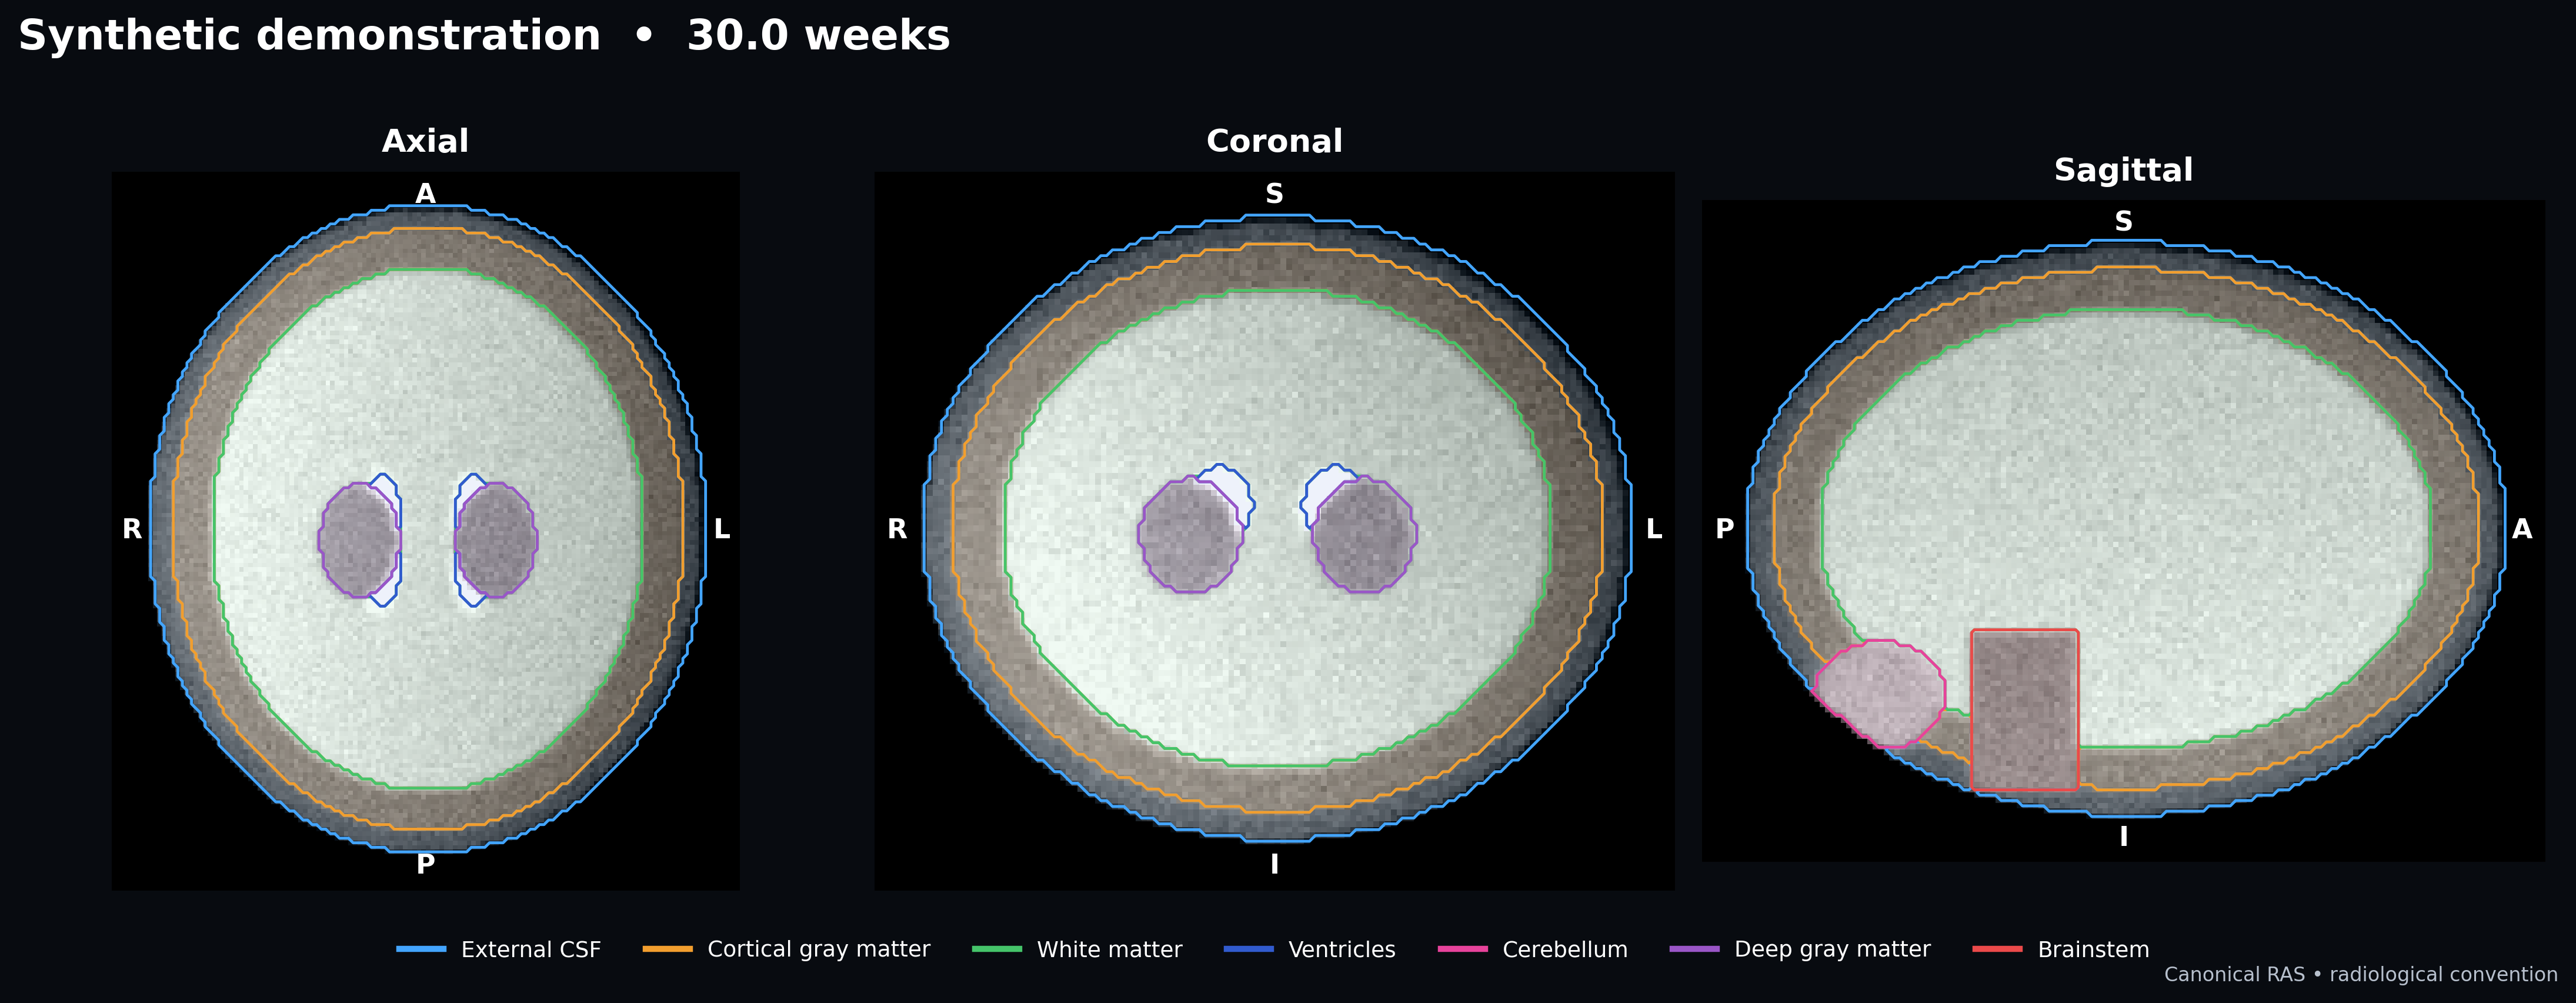

In [2]:
out = Path('demo_outputs'); out.mkdir(exist_ok=True)
image, segmentation = make_synthetic_phantom(out/'synthetic_svr.nii.gz', out/'synthetic_seg.nii.gz')
figure = save_radiology_figure(image, segmentation, out/'segmentation_qc.png', subject_id='Synthetic demonstration', gestational_age_weeks=30.0, fill_alpha=0.08)
display(Image(filename=str(figure), width=1200))

## Affine-aware volumes

Voxel volume is computed from the determinant of the NIfTI affine. The native seven tissues and definition-aware Ren aggregates are reported separately.

In [3]:
tissues, aggregates, qc = measure_segmentation(segmentation, subject_id='demo', gestational_age_weeks=30.0)
display(tissues[['region','volume_ml']].round(2))
display(aggregates[['region','volume_ml']].round(2))
qc

,region,volume_ml
0,external_csf,107.64
1,cortical_gray_matter,139.38
2,white_matter,228.16
3,ventricles,1.84
4,cerebellum,17.20
5,deep_gray_matter,4.68
6,brainstem,4.24


,region,volume_ml
0,total_brain,393.65
1,intracranial_volume,503.13
2,cortical_gray_matter,139.38
3,subcortical_brain_tissue,232.84
4,external_csf,107.64
5,ventricles,1.84
6,cerebellum,17.20
7,brainstem,4.24


{'foreground_voxels': 982672,
 'connected_components': 1,
 'largest_component_fraction': 1.0,
 'touches_image_boundary': False,
 'missing_labels': [],
 'warnings': [],
 'subject_id': 'demo',
 'shape': [144, 160, 136],
 'voxel_volume_ml': 0.000512000022888184,
 'orientation': 'RAS'}

## Multi-quantile chart

The bundled Ren table mode reconstructs centiles from weekly mean/SD under an explicit Normal approximation. It is not a FetalSynthSeg-native clinical norm.

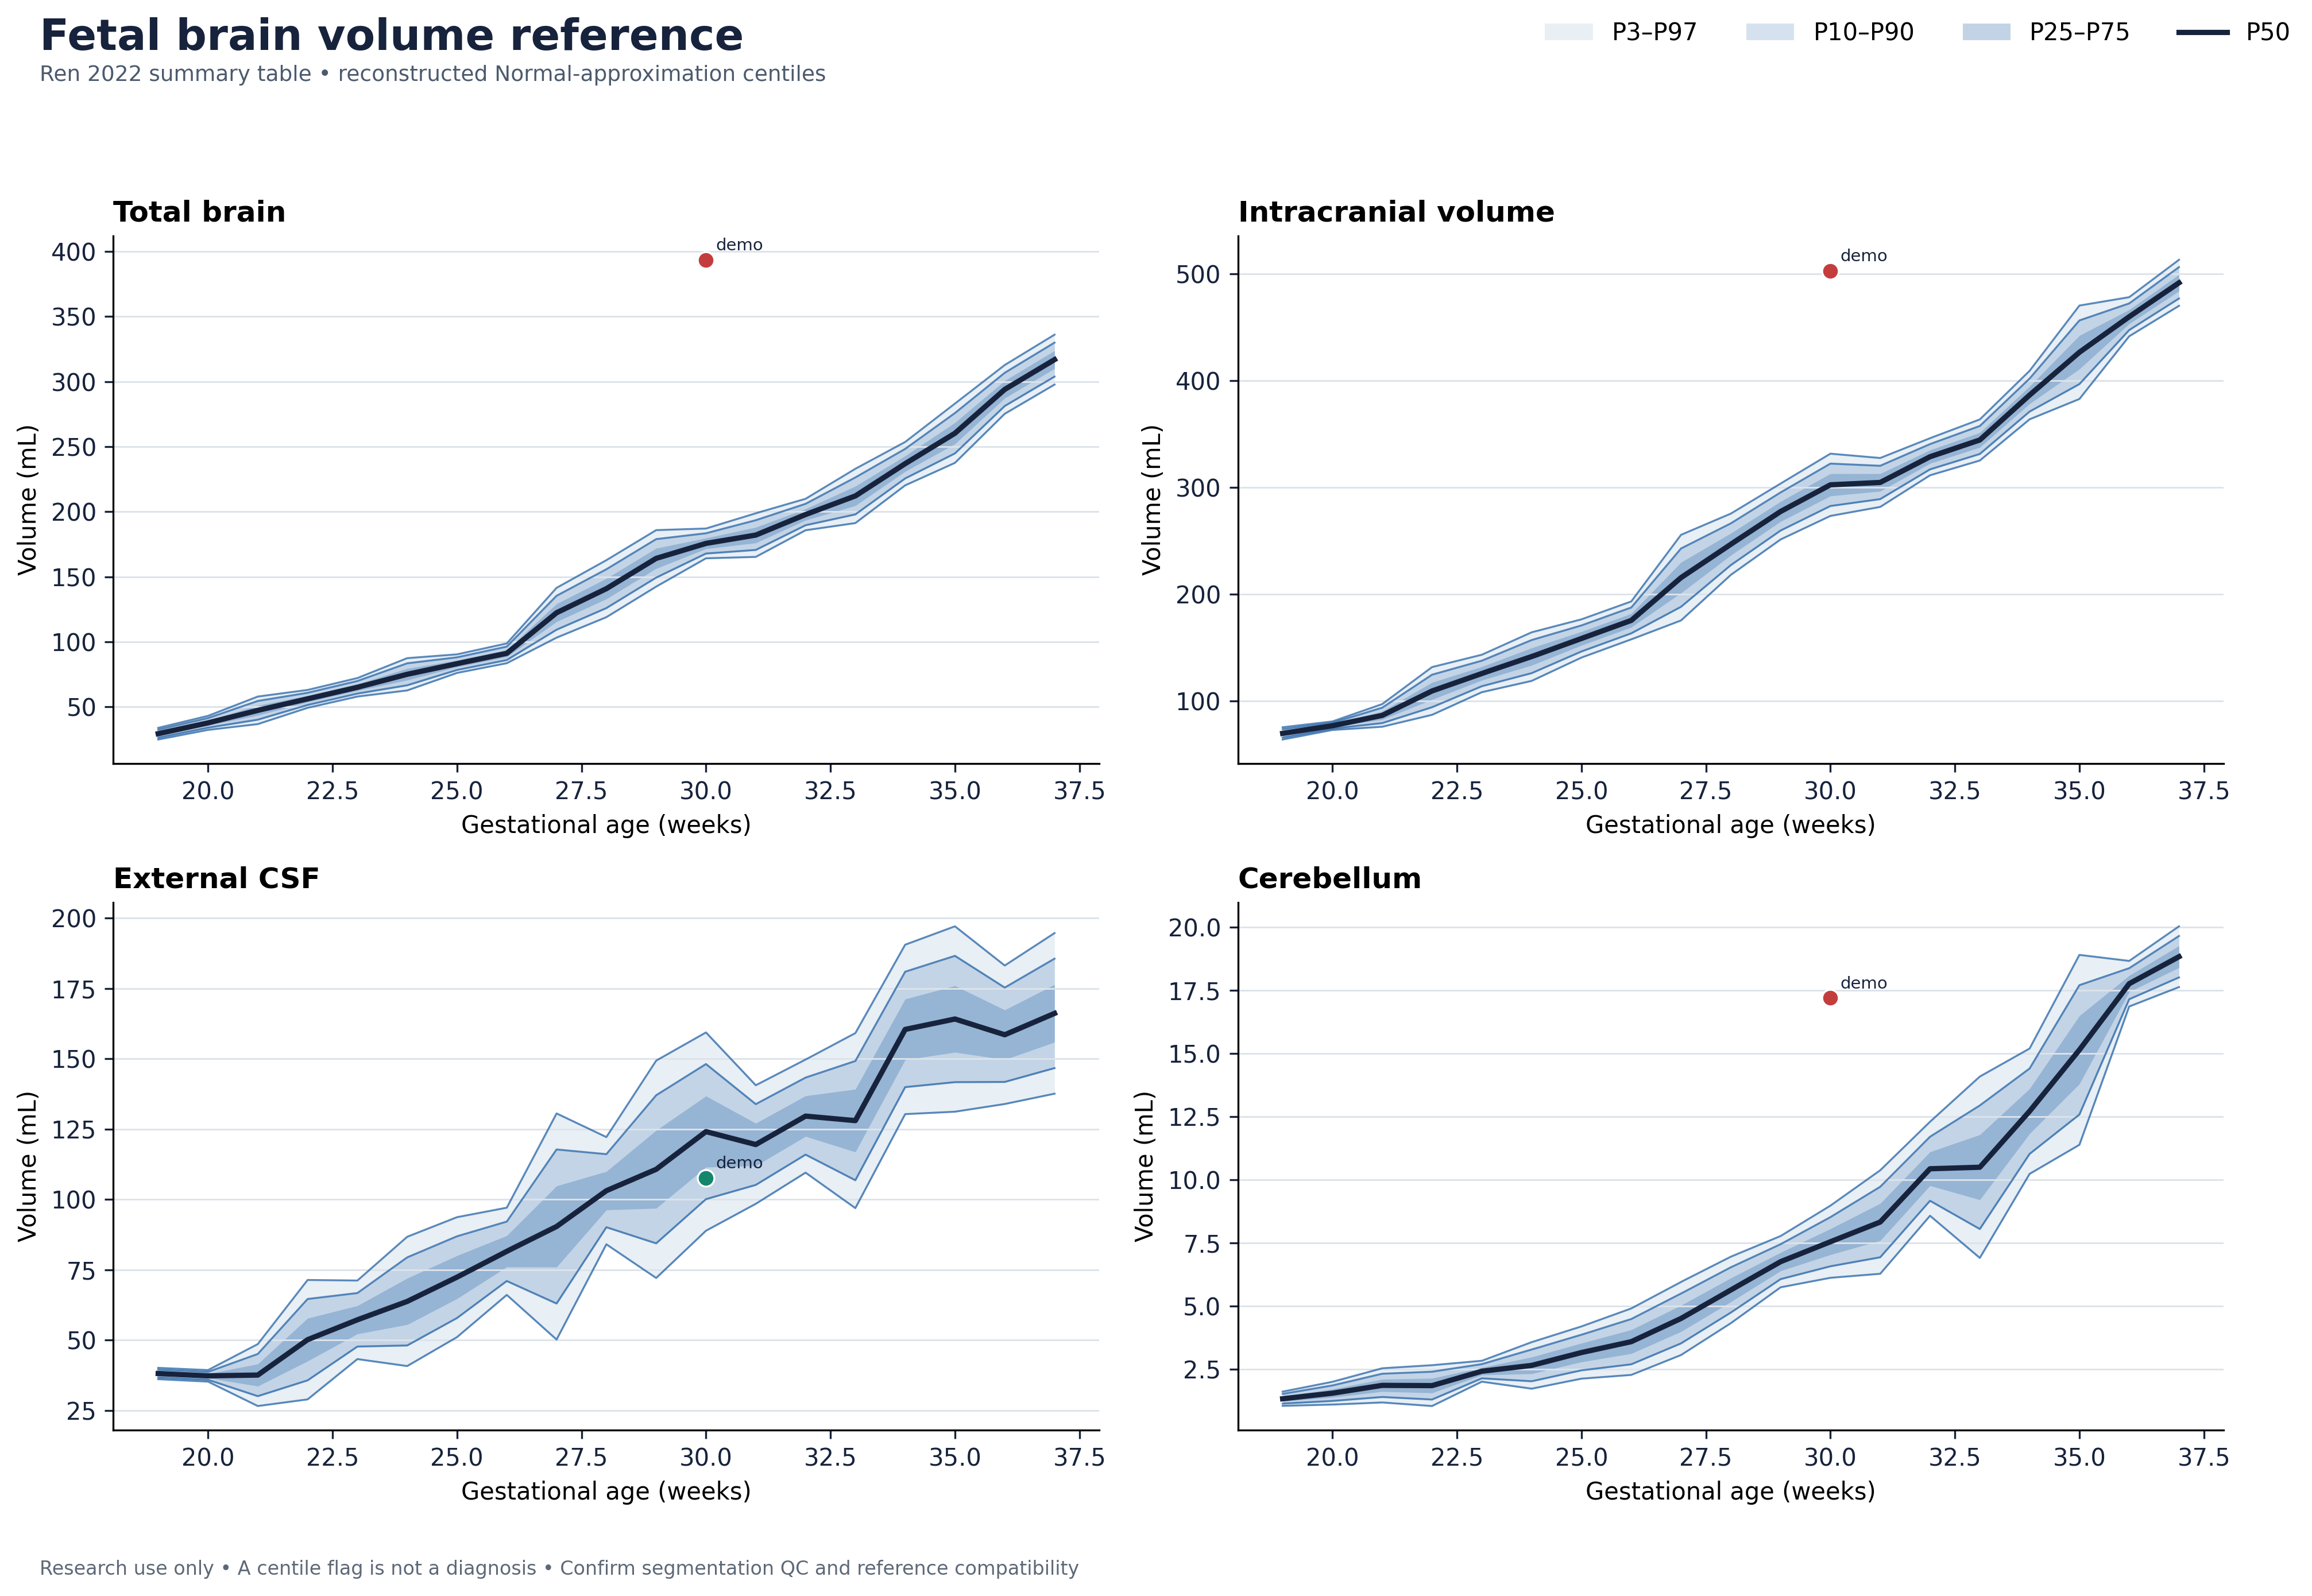

,region,volume_ml,estimated_percentile_bounded,status,interpretation_note
0,total_brain,393.647122,97.000000,high_reference_flag,Definition-aligned research comparison; local ...
1,intracranial_volume,503.128086,97.000000,high_reference_flag,Definition-aligned research comparison; local ...
2,cortical_gray_matter,139.375622,97.000000,comparison_only_definition_mismatch,FeTA and reference cortical boundaries differ.
3,subcortical_brain_tissue,232.837130,97.000000,comparison_only_definition_mismatch,White/deep-gray allocation differs between pro...
4,external_csf,107.637765,19.948612,within_reference_interval,Definition-aligned research comparison; local ...
5,ventricles,1.843200,12.262167,comparison_only_definition_mismatch,The reference measures lateral ventricles; FeT...
6,cerebellum,17.195009,97.000000,high_reference_flag,Definition-aligned research comparison; local ...
7,brainstem,4.239360,96.379882,comparison_only_definition_mismatch,FeTA may include spinal cord with brainstem.


In [4]:
curves, metadata = build_table_curves(method='interpolate')
scores = score_against_curves(aggregates, curves)
chart = save_growth_chart(curves, out/'growth_chart.png', observations=scores, regions=['total_brain','intracranial_volume','external_csf','cerebellum'], subtitle='Ren 2022 summary table • reconstructed Normal-approximation centiles')
display(Image(filename=str(chart), width=1200))
display(scores[['region','volume_ml','estimated_percentile_bounded','status','interpretation_note']])

## Model choices

- `build_table_curves(method='interpolate')`: reproduces weekly means; default.
- `method='quadratic'`, `'cubic'`, or `'auto'`: smooths mean and log-SD; auto uses leave-one-week-out error.
- `fit_local_quantile_reference(..., method='spline')`: preferred for a reviewed, protocol-matched control cohort.
- `published_polynomial_curve('jarvis2016_total_brain')`: published mean equation only; no invented bands.